In [63]:
import numpy as np
import sage.all as sage
from sage.all import sin, cos, pi, ln, diff
from ic_generator import generate_ic_grid, get_ic_grid_info
from state_helpers import StateAccessor
from ode_viewer_nD import ODESystemND, ODEViewerND

In [64]:
# ============================================================================
# CONFIGURATION - Change N_VARS to adapt everything automatically!
# ============================================================================

N_VARS = 3  # Number of variables

# --- Numerical Settings ---
t_start = -20.0  # Start time
t_end = 30.0  # End time
num_points = 1000  # Number of points for trajectory (higher = smoother)
step_size = 0.01  # Integration step size

max_boundary = 50  # Maximum axis limit for plot boundaries (None = auto)
compute_boundary = 2 * max_boundary if max_boundary else None  # Stop computation when values exceed this

# --- Initial Conditions (automatically scales with N_VARS) ---
IC_CENTER = 0.0  # Center of initial condition grid
IC_SPREAD = 1.0  # Spread around center (by unit)
ICS_PER_VAR = 3  # Number of ICs along each dimension

# --- Projection Settings ---
# Which 3 variables to use as (x_axis, y_axis, z_axis) in the 3D plot
# 0 = time, 1 = first var, 2 = second var, 3 = third var, ...
projection_axes = [0, 1, 2]  # Works for any N_VARS (len MUST equal 3)
color_by = 0  # Which variable to color by (0 = t, 1 = x, 2 = y, ...) or None

# --- Display Settings ---
figsize = (10, 8)  # Figure size (width, height)
title = "Phase Space"  # Plot title

# --- Output Settings ---
save_plot = True  # Save the plot to a file
save_path = "./Plots/3D/3D_NSYS_ODE.png"

# --- Live Viewer Settings ---
use_threejs = True
threejs_filename = "./Plots/3D/3D_NSYS_ODE.html"

In [65]:
# ============================================================================
# SYSTEM DEFINITION
# ============================================================================

first_order_system = False  # Set to True for first-order systems like Lorenz
ode_order = N_VARS if not first_order_system else None

if first_order_system:
    # First-order system: define dx/dt for each variable
    # Generate variables
    VAR_NAMES = [f"x_{i}" if i > 0 else "x" for i in range(N_VARS)]

    # Example: Each variable's derivative is sine of the next variable
    # derivs = []
    # for i in range(N_VARS):
    #     next_idx = (i + 1) % N_VARS
    #     derivs.append(sin(state[next_idx]))
    # return derivs
    
    # Alternatively, use StateAccessor for named access:
    # s = StateAccessor(state, VAR_NAMES)
    # dx = sin(s.x_1) if N_VARS > 1 else 0
    # dy = sin(s.x_2) if N_VARS > 2 else 0
    # dz = sin(s.x_0)
    # return [dx, dy, dz, ...]

    def system_func(t, state):
        # state = [dx₁/dt, dx₂/dt, ...]

        derivs = []
        for i in range(N_VARS):
            next_idx = (i + 1) % N_VARS
            derivs.append((state[next_idx] / t) - (t / state[next_idx]))
        return derivs

else:
    # Higher-order system: define dⁿx/dtⁿ
    VAR_NAMES = ["x"] + [("d" * i) + "x" for i in range(1, ode_order)]

    def highest_derivative(t, state):
        # state = [x, dx/dt, d²x/dt², ..., dⁿ⁻¹x/dtⁿ⁻¹]
        s = StateAccessor(state, VAR_NAMES)

        return s.dx * s.ddx + t**2 # return dⁿx/dtⁿ

In [66]:
# GENERATE INITIAL CONDITIONS

ic_grid = generate_ic_grid(N_VARS, IC_CENTER, IC_SPREAD, ICS_PER_VAR)
total_ics = get_ic_grid_info(N_VARS, ICS_PER_VAR)

print(f"System: {N_VARS}-variable system")
print(f"Variables: {VAR_NAMES}")
print(f"Initial conditions: {total_ics} trajectories")
print(f"IC grid: {len(ic_grid)} total points")
print(f"Time span: [{t_start}, {t_end}]")
print()

System: 3-variable system
Variables: ['x', 'dx', 'ddx']
Initial conditions: 27 trajectories
IC grid: 27 total points
Time span: [-20.0, 30.0]



Completed trajectory 1 of 27
Completed trajectory 2 of 27
Completed trajectory 3 of 27
Completed trajectory 4 of 27
Completed trajectory 5 of 27
Completed trajectory 6 of 27
Completed trajectory 7 of 27
Completed trajectory 8 of 27
Completed trajectory 9 of 27
Completed trajectory 10 of 27
Completed trajectory 11 of 27
Completed trajectory 12 of 27
Completed trajectory 13 of 27
Completed trajectory 14 of 27
Completed trajectory 15 of 27
Completed trajectory 16 of 27
Completed trajectory 17 of 27
Completed trajectory 18 of 27
Completed trajectory 19 of 27
Completed trajectory 20 of 27
Completed trajectory 21 of 27
Completed trajectory 22 of 27
Completed trajectory 23 of 27
Completed trajectory 24 of 27
Completed trajectory 25 of 27
Completed trajectory 26 of 27
Completed trajectory 27 of 27
✓ Solved 27 trajectories


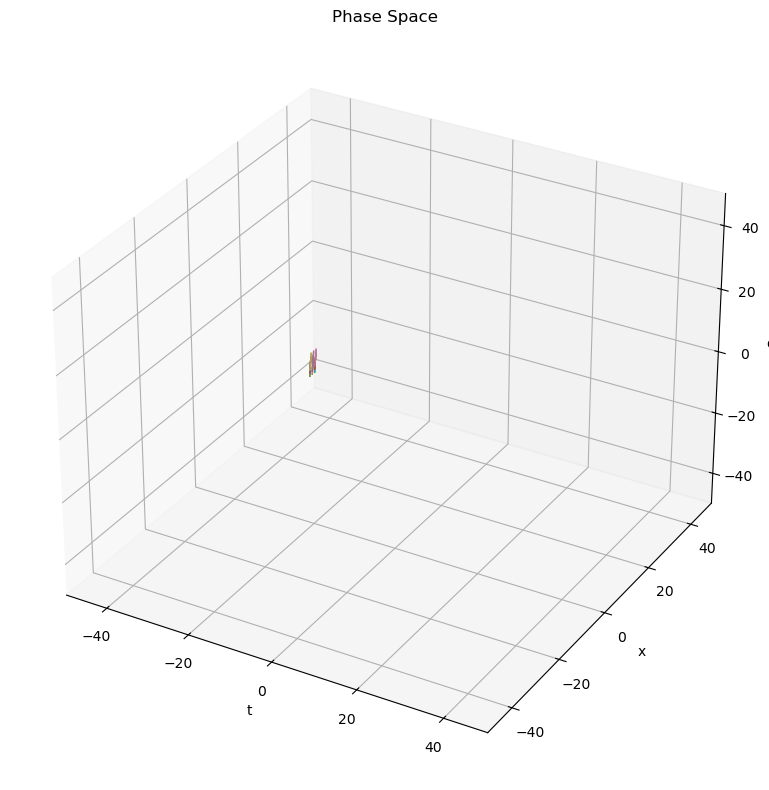

✓ Plotted phase space with projection axes [0, 1, 2]


In [67]:
# RUNNING AND PLOTTING

if first_order_system:
    system = ODESystemND(system_func, N_VARS, VAR_NAMES)
else:
    system = ODESystemND.from_higher_order(highest_derivative, ode_order, VAR_NAMES)

t_eval = np.linspace(t_start, t_end, num_points)
viewer = ODEViewerND()

viewer.solve_ics_grid(
    system,
    (t_start, t_end),
    ic_grid,
    total_ics,
    t_eval=t_eval,
)

print(f"✓ Solved {len(viewer.solutions)} trajectories")

viewer.plot_all_3d(
    projection_axes=projection_axes,
    color_variable=color_by,
    figsize=figsize,
    title=title,
    save_path=save_path if save_plot else None,
    max_boundary=max_boundary,
    compute_boundary=compute_boundary,
)

print(f"✓ Plotted phase space with projection axes {projection_axes}")

In [68]:
# THREE.JS INTERACTIVE VIEWER

if use_threejs:
    traj_data = viewer.get_threejs_trajectories(
        projection_axes=projection_axes,
        color_variable=color_by,
        compute_boundary=compute_boundary,
    )

    plot_obj = sage.Graphics()

    for idx, traj in enumerate(traj_data):
        points = traj["points"]

        if color_by is not None and traj.get("normalized_colors") is not None:
            colors = traj["normalized_colors"]
            for i in range(0, len(points) - 1):
                color_val = colors[i]
                segment = sage.line3d(
                    [points[i], points[i + 1]],
                    color=sage.hue(color_val),
                    thickness=2,
                    opacity=0.8,
                )
                plot_obj += segment
        else:
            traj_color = traj.get("trajectory_color", 0)
            line = sage.line3d(
                points,
                color=sage.hue(traj_color),
                thickness=2,
                opacity=0.8,
            )
            plot_obj += line
        print(f"Completed trajectory {idx + 1} of {len(traj_data)}")
        
    if color_by is not None:
        print(f"Color by: {color_by} ({VAR_NAMES[color_by-1] if 0 < color_by <= N_VARS else 'time'})")

    plot_obj.save(threejs_filename, viewer="threejs", online=True)
    print(f"✓ Three.js plot saved to: {threejs_filename}")
    sage.show(plot_obj)

Completed trajectory 1 of 27
Completed trajectory 2 of 27
Completed trajectory 3 of 27
Completed trajectory 4 of 27
Completed trajectory 5 of 27
Completed trajectory 6 of 27
Completed trajectory 7 of 27
Completed trajectory 8 of 27
Completed trajectory 9 of 27
Completed trajectory 10 of 27
Completed trajectory 11 of 27
Completed trajectory 12 of 27
Completed trajectory 13 of 27
Completed trajectory 14 of 27
Completed trajectory 15 of 27
Completed trajectory 16 of 27
Completed trajectory 17 of 27
Completed trajectory 18 of 27
Completed trajectory 19 of 27
Completed trajectory 20 of 27
Completed trajectory 21 of 27
Completed trajectory 22 of 27
Completed trajectory 23 of 27
Completed trajectory 24 of 27
Completed trajectory 25 of 27
Completed trajectory 26 of 27
Completed trajectory 27 of 27
Color by: 0 (time)
✓ Three.js plot saved to: ./Plots/3D/3D_NSYS_ODE.html
Graphics3d Object
